In [2]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [3]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [4]:
def get_cell_orders(mouse, session_deets, days, match_inds):
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
            
    
    cell_order = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets,tuple):
            roi_inds = []
            for _deets in deets:
                roi_inds.append(_deets['ravel_ind'])
            print(roi_inds)
            mapping = u.common_rois(match_inds, roi_inds)
            
            cell_order.append(mapping[0,:].tolist())
        else:
            cell_order.append([])
    return cell_order

def common_rois_adjust(mouse, days):
    if mouse in ctrl_mice:
        session_deets = stx.ymaze_sess_deets.CTRL_sessions[mouse]
    else:
        session_deets = stx.ymaze_sess_deets.KO_sessions[mouse]
    
    
    ravel_inds = []
    day_inds = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets, tuple):
            for _deets in deets:
                ravel_inds.append(_deets['ravel_ind'])
                day_inds.append(day)
        else:
            ravel_inds.append(deets['ravel_ind'])
            day_inds.append(day)

    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
    with open(os.path.join(pkldir, "roi_aligner_results.pkl"), 'rb') as file:
        match_inds = dill.load(file)
    

    common_roi_mapping = u.common_rois(match_inds, ravel_inds)
    c_rows = []
    for i, d in enumerate(day_inds):
        if d != day_inds[i-1]:
            c_rows.append(i)
    
    common_roi_mapping = common_roi_mapping[c_rows,:]
    cell_order = get_cell_orders(mouse,session_deets, days, match_inds)

    roi_mapping_adj = np.zeros(common_roi_mapping.shape)
    c_cols = []
    for row, order in enumerate(cell_order):
        croi = common_roi_mapping[row,:]

        if len(order)==0:
            roi_mapping_adj[row,:] = croi
        else:
            for col, _c in enumerate(croi):
                match = np.argwhere(order==_c)
                if len(match)>0:
                    c_cols.append(col)
                    roi_mapping_adj[row,col]=match[0][0]
                    
                    
    if len(c_cols) !=0:
        roi_mapping_adj = roi_mapping_adj[:,c_cols]
    return roi_mapping_adj.astype(int)


def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(6):

        corr_dict[react_day] = {}
        # sess = u.load_single_day(mouse, react_day)

        for tt_corr_day in range(react_day,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = common_rois_adjust(mouse, days)


                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                # sess = u.load_single_day(mouse, react_day)

                # trial matrix 
                with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                    hse_tt_corr = pickle.load(file)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr!=hse_react.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr==hse_react.novel_arm
                

                
                # react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                ts_mask = lr_mask * (hse_react.post_reward_bool>0)
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)
                
                if ts_mask.sum()<10:
                    corr_dict[react_day][tt_corr_day][key]['tt_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['hse_corr']=[np.nan,]
                    continue
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)

                r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                                        hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
                # pop_act = sess.timeseries['F_dff'].mean(axis=0)
                # # r, _ = sp.stats.pearsonr(pop_act[np.newaxis,ts_mask],
                # #                          sess.timeseries['F_dff'][common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
                # r, _ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                #                          sess.timeseries['F_dff'][common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
               
                
                trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

                for cell in range(trial_mat.shape[-1]):
                    corr_mat[:,:,cell] = np.corrcoef(trial_mat[:,:,cell])

                for cell in range(corr_mat.shape[-1]):
                    _mat = corr_mat[:, :,cell]
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.array([np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([r]).flatten()
                
    return corr_dict

def predict_across_day_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    # common_roi_mapping = common_rois_adjust(mouse, np.arange(6))
    for react_day in range(5):
        corr_dict[react_day] = {}
        for tt_corr_day in range(react_day+1,6):
            corr_dict[react_day][tt_corr_day] ={}
            days = [react_day, tt_corr_day]

            common_roi_mapping = common_rois_adjust(mouse, days)
            


            with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                hse_react = pickle.load(file)

            
            
            # trial matrix 
            with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                hse_fut = pickle.load(file)
              
            
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                
                if key == 'fam':
                    trial_mask_react = hse_react.trial_info['LR']!=hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']!=hse_fut.novel_arm
                else:
                    trial_mask_react = hse_react.trial_info['LR']==hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']==hse_fut.novel_arm

                tmat_react = np.nanmean(hse_react.trial_mat[trial_mask_react, :, :][:, :, common_roi_mapping[0,:]], axis=0)
                tmat_fut = np.nanmean(hse_fut.trial_mat[trial_mask_fut, :, :][:, :, common_roi_mapping[1,:]], axis=0)

                tmat_react[np.isnan(tmat_react)]=0
                tmat_fut[np.isnan(tmat_fut)]=0
                

                react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                
                hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
                                        react_spks_ledge[:,hse_react.post_reward_bool>0][common_roi_mapping[0,:],:], axis=-1)
                

                
                cell_r, _ = sp.stats.pearsonr(tmat_react, tmat_fut, axis=0)

                


                corr_dict[react_day][tt_corr_day][key]['cell_corr']=np.array([cell_r]).ravel()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([hse_r]).ravel()
                # except:
                #     corr_dict[react_day][tt_corr_day][key]['activated']=np.nan
                #     corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nan
                    
    return corr_dict


In [ ]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                for ttype in ('fam', 'nov'):
                
                    hse_corr = corr_dict[i][j][ttype]['hse_corr']
                    tt_corr =  corr_dict[i][j][ttype]['tt_corr']
                    # print(hse_corr.shape)
                    
                    nanmask = np.isnan(np.array(hse_corr).flatten()*np.array(tt_corr).flatten())
                    nanmask = np.array([nanmask,]).ravel()
                    if nanmask.shape[0]==1:
                        continue
                    # print(hse_corr)
                    hse_corr[nanmask] = 0
                

                    for hse, tt in zip(hse_corr, tt_corr):
                        rows.append({'condition':cond,
                                    'mouse':mouse,
                                    'ttype': ttype,
                                    'hse_day':i,
                                    'tt_day':j,
                                    'hse_corr':hse,
                                    'tt_corr':tt})
df = pd.DataFrame(rows)


4467331.1
4467331.1


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

4467331.2
4467331.2


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]


...

/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


4467332.1
4467332.1


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


In [ ]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0

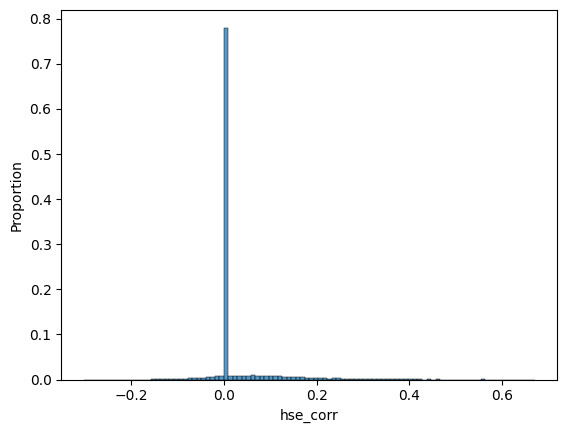

In [ ]:
fig, ax = plt.subplots()
_ = sns.histplot(data = df,
                 x='hse_corr', bins=100, stat='proportion', ax = ax)

# ax.set_ylim([0,.1])

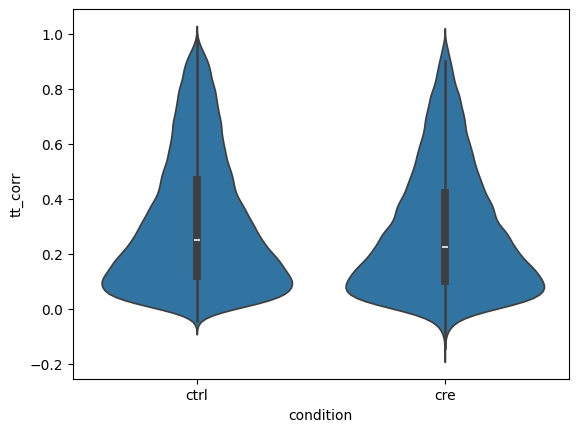

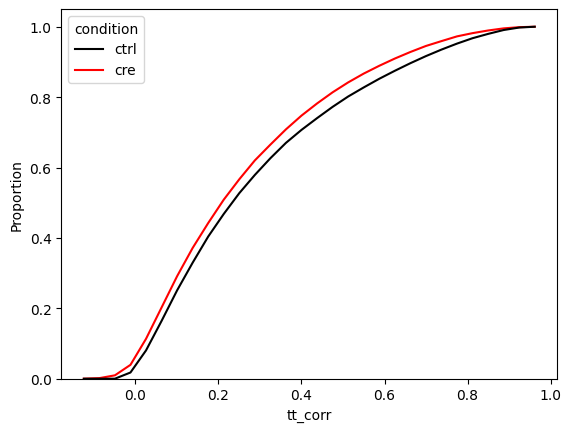

In [ ]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df, x='condition', y='tt_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df,
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

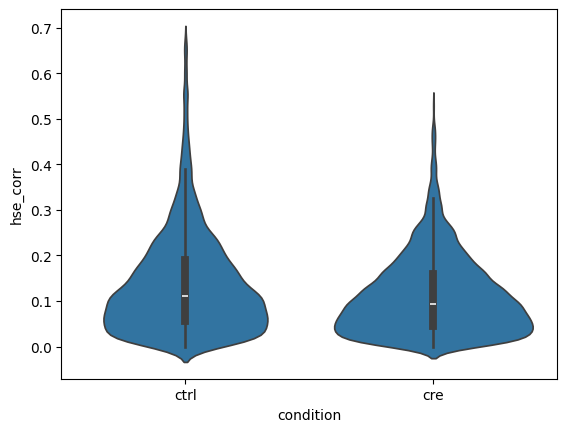

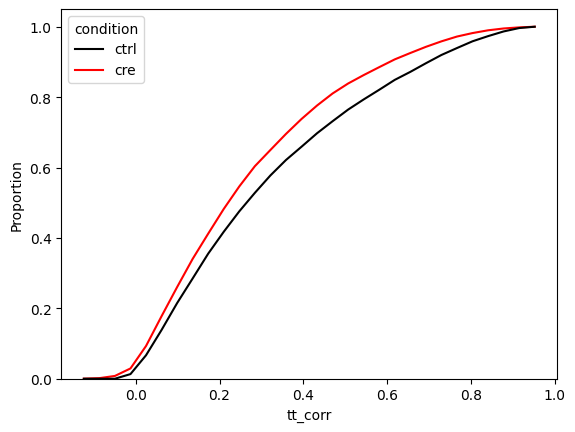

In [ ]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df.loc[nonzero_mask,:], x='condition', y='hse_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df.loc[nonzero_mask,:],
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

In [ ]:


print(df.loc[cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[cre_mask*(~nonzero_mask),'tt_corr'].mean())
print(df.loc[~cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[~cre_mask*(~nonzero_mask),'tt_corr'].mean())

0.28865739211522196 0.27994957661112074
0.3380658254946667 0.30899030858567617


In [ ]:
df.head()

,condition,mouse,hse_day,tt_day,hse_corr,tt_corr,hse_corr_z,tt_corr_z
0,ctrl,4467331.1,0,1,0.000000,0.091567,0.000000,0.091825
1,ctrl,4467331.1,0,1,-0.008332,0.548356,-0.008333,0.616028
2,ctrl,4467331.1,0,1,0.000000,0.124787,0.000000,0.125441
3,ctrl,4467331.1,0,1,0.058633,0.110284,0.058700,0.110734
4,ctrl,4467331.1,0,1,-0.194914,0.473595,-0.197440,0.514695


In [ ]:
df['hse_corr_z'] = np.arctanh(df['hse_corr'])
df['tt_corr_z'] = np.arctanh(df['tt_corr'])
df_pos = df.loc[nonzero_mask].groupby(['condition','hse_day', 'mouse']).mean().reset_index()
df_neg = df.loc[~nonzero_mask].groupby(['condition','hse_day',  'mouse']).mean().reset_index()
df_pos['positive']= True
df_neg['positive']= False

NameError: name 'np' is not defined

In [ ]:
df_grouped = pd.concat([df_pos, df_neg], axis=0)

In [ ]:
df_grouped.head()

,condition,hse_day,tt_day,mouse,hse_corr,tt_corr,hse_corr_z,tt_corr_z,positive
0,cre,0,1,4467975.1,0.146378,0.156406,0.149868,0.162975,True
1,cre,0,1,4467975.2,0.224012,0.153471,0.234492,0.164073,True
2,cre,0,1,4467975.3,0.151831,0.233056,0.154764,0.252103,True
3,cre,0,1,4467975.4,0.146777,0.274366,0.150086,0.300075,True
4,cre,0,1,4467975.5,0.136525,0.317427,0.140207,0.366398,True


Text(0.5, 1.0, 'STX3KO')

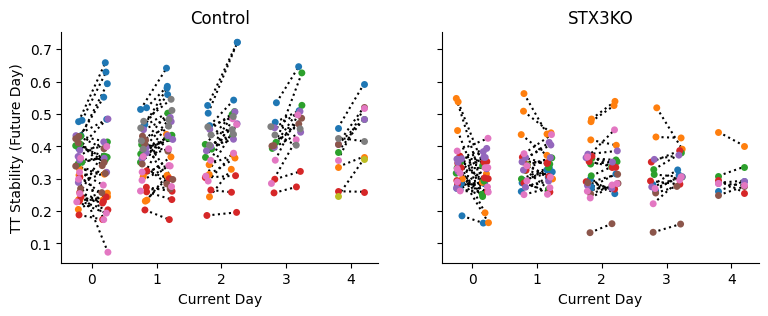

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(9,3), sharex=True, sharey=True)


old_ind = 0
for i, mouse in enumerate(ctrl_mice):
    _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse)]
    color = plt.cm.tab10(i)
    _ = sns.stripplot(data= _df,
                        x='hse_day', 
                        y='tt_corr', 
                        hue='positive',
                        palette=[color, color], 
                        hue_order=[False, True],
                        dodge=True, legend=False,
                        ax=ax[0])
    new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
    for d in range(old_ind,new_ind,2):
        for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
            ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
    old_ind = new_ind
    


old_ind = 0
for i, mouse in enumerate(ko_mice):
    _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse)]
    color = plt.cm.tab10(i)
    _ = sns.stripplot(data= _df,
                        x='hse_day', 
                        y='tt_corr', 
                        hue='positive',
                        palette=[color, color], 
                        hue_order=[False, True],
                        dodge=True, legend=False,
                        ax=ax[1])
    
    new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
    for d in range(old_ind,new_ind,2):
        for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
            ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
    old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('TT Stability (Future Day)')
ax[0].set_title('Control')
ax[1].set_title('STX3KO')


In [ ]:
import statsmodels.formula.api as smf
df_tmp = df_grouped.copy()
df_tmp['condition'] = df_tmp['condition'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['hse_day'] = df_tmp['hse_day'].astype('category')
# df_tmp['tt_day'] = df_tmp['tt_day'].astype('category')
# df_tmp['day_pair'] = df_tmp['hse_day'].astype(str) + '_' + df_tmp['tt_day'].astype(str)
# df_tmp['day_pair'] = df_tmp['day_pair'].astype('category')
# df_tmp['hse_z'] = np.arctanh(df_tmp['hse_corr'])
# df_tmp['tt_z'] = np.arctanh(df_tmp['tt_corr'])
# df_tmp['hse_corr_rank'] = df_tmp['hse_corr'].rank()
df_tmp['positive'] = df_tmp['positive'].astype('category')
df_tmp['tt_corr_rank'] = df_tmp['tt_corr'].rank()
model = smf.mixedlm("tt_corr_rank ~ positive * condition + hse_day", df_tmp, groups=df_tmp["mouse"])

In [ ]:
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                     MixedLM        Dependent Variable:        tt_corr_rank
No. Observations:          414            Method:                    REML        
No. Groups:                16             Scale:                     4671.7666   
Min. group size:           2              Log-Likelihood:            -2292.1755  
Max. group size:           30             Converged:                 Yes         
Mean group size:           25.9                                                  
---------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                            66.681   38.059  1.752 0.080  -7.914 141.276
positive[T.True]                     -0.854    9.866 -0.087 0.931 -20.190  18.482
condition[T.ctrl]                    57.018   47.891  1.191 0.234 -36.846 150.881
day_pair[T.0_2]                      47.308   18.957  2.496 0.013  10.153  84.463
day_pair[T.0_3]                      97.654   18.957  5.151 0.000  60.499 134.809
day_pair[T.0_4]                      84.923   18.957  4.480 0.000  47.768 122.078
day_pair[T.0_5]                      57.538   18.957  3.035 0.002  20.383  94.693
day_pair[T.1_2]                      61.828   18.649  3.315 0.001  25.276  98.380
day_pair[T.1_3]                     122.221   18.649  6.554 0.000  85.669 158.773
day_pair[T.1_4]                     119.292   18.649  6.397 0.000  82.741 155.844
day_pair[T.1_5]                      87.185   18.649  4.675 0.000  50.633 123.737
day_pair[T.2_3]                     140.294   18.736  7.488 0.000 103.572 177.017
day_pair[T.2_4]                     109.223   18.736  5.829 0.000  72.500 145.945
day_pair[T.2_5]                      93.223   18.736  4.976 0.000  56.500 129.945
day_pair[T.3_4]                     125.030   18.733  6.674 0.000  88.314 161.746
day_pair[T.3_5]                     102.995   18.733  5.498 0.000  66.279 139.711
day_pair[T.4_5]                     105.843   18.350  5.768 0.000  69.877 141.809
positive[T.True]:condition[T.ctrl]   39.620   13.472  2.941 0.003  13.215  66.025
Group Var                          8577.303   50.034                             
=================================================================================

"""

Shapiro-Wilk: W=0.989, p=0.00451
D'Agostino: χ²=9.783, p=0.00751


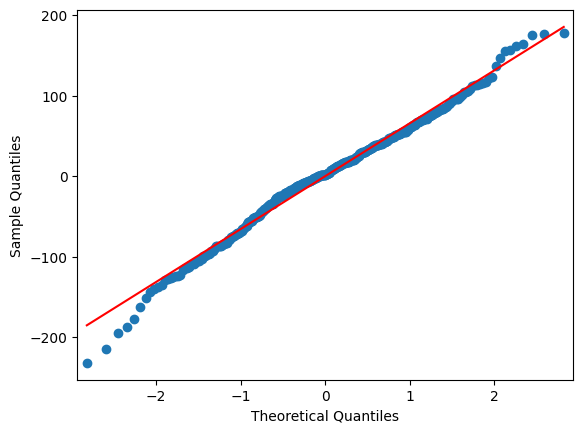

In [ ]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [ ]:
# permutation test

In [ ]:
# rerun with across day correlation